In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint

from sklearn.feature_selection import SelectKBest, chi2, f_classif, f_regression

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, Binarizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

sns.set_style("whitegrid")


In [2]:
def load_and_preprocess(file_path):

    # Load Dataset
    df = pd.read_csv(file_path)

    print("=" * 70)
    print("DATASET LOADED SUCCESSFULLY")
    print("=" * 70)

    print("Shape :", df.shape)

    print("\nDataset Information")
    df.info()

    # Duplicate Rows
    duplicates = df.duplicated().sum()
    print("\nDuplicate Rows :", duplicates)

    df.drop_duplicates(inplace=True)

    # Remove Empty Rows and Columns
    df.dropna(axis=0, how="all", inplace=True)
    df.dropna(axis=1, how="all", inplace=True)

    # Replace Missing Value Symbols
    df.replace(
        ["?", "NA", "N/A", "na", "null", "NULL", ""],
        np.nan,
        inplace=True
    )

    # Remove Extra Spaces
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()

    # Convert Numeric Strings (only when the WHOLE column is numeric-convertible)
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except (ValueError, TypeError):
            pass

    # Missing Value Percentage
    print("\nMissing Value Percentage")

    missing_percent = (df.isnull().sum() / len(df)) * 100
    print(missing_percent)

    # Drop Columns with More Than 50% Missing Values
    cols = missing_percent[missing_percent > 50].index

    if len(cols) > 0:
        print("\nDropped Columns :", list(cols))

    df.drop(columns=cols, inplace=True)

    # Fill Missing Values (direct assignment - avoids silent no-op under Copy-on-Write)
    for col in df.columns:

        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())

        else:
            df[col] = df[col].fillna(df[col].mode()[0])

    # Remove Constant Columns
    constant_cols = []

    for col in df.columns:

        if df[col].nunique() == 1:
            constant_cols.append(col)

    if constant_cols:
        print("\nRemoved Constant Columns :", constant_cols)

    df.drop(columns=constant_cols, inplace=True)

    # Encode Categorical Columns
    categorical_cols = df.select_dtypes(include="object").columns

    encoder = LabelEncoder()

    for col in categorical_cols:
        df[col] = encoder.fit_transform(df[col])

    print("\nPreprocessing Completed Successfully")
    print("Final Shape :", df.shape)

    return df


In [3]:
def perform_eda(df):

    print("=" * 70)
    print("DATASET SUMMARY")
    print("=" * 70)

    print("\nShape")
    print(df.shape)

    print("\nColumns")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nUnique Values")
    print(df.nunique())

    print("\nSummary Statistics")
    print(df.describe(include="all"))

    numeric_cols = df.select_dtypes(include=np.number).columns
    categorical_cols = df.select_dtypes(exclude=np.number).columns

    # Missing Values Heatmap
    plt.figure(figsize=(6, 3))
    sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
    plt.title("Missing Values Heatmap")
    plt.show()

    # Correlation Heatmap
    if len(numeric_cols) > 1:

        plt.figure(figsize=(12, 10))
        sns.heatmap(
            df[numeric_cols].corr(),
            cmap="coolwarm"
        )
        plt.title("Correlation Heatmap")
        plt.show()

    # Histograms of a subset of important features (first 12 numeric columns, excluding target)
    hist_cols = [c for c in numeric_cols if c != "class"][:12]
    df[hist_cols].hist(figsize=(14, 8), bins=20)
    plt.suptitle("Histograms of Key Features")
    plt.tight_layout()
    plt.show()

    # Boxplots for the same subset
    plt.figure(figsize=(14, 6))
    for i, col in enumerate(hist_cols, 1):
        plt.subplot(3, 4, i)
        sns.boxplot(x=df[col])
        plt.title(col, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Count Plots for categorical columns (if any)
    for col in categorical_cols:
        plt.figure(figsize=(5, 3))
        sns.countplot(x=df[col])
        plt.xticks(rotation=45)
        plt.title(col)
        plt.show()


DATASET LOADED SUCCESSFULLY
Shape : (4601, 58)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   class                       4601 non-null   int64  
 1   word_freq_make              4601 non-null   float64
 2   word_freq_address           4601 non-null   float64
 3   word_freq_all               4601 non-null   float64
 4   word_freq_3d                4601 non-null   float64
 5   word_freq_our               4601 non-null   float64
 6   word_freq_over              4601 non-null   float64
 7   word_freq_remove            4601 non-null   float64
 8   word_freq_internet          4601 non-null   float64
 9   word_freq_order             4601 non-null   float64
 10  word_freq_mail              4601 non-null   float64
 11  word_freq_receive           4601 non-null   float64
 12  word_freq_will              4601 

             class  word_freq_make  word_freq_address  word_freq_all  \
count  4210.000000     4210.000000        4210.000000    4210.000000   
mean      0.398812        0.104366           0.112656       0.291473   
std       0.489712        0.300005           0.454260       0.515719   
min       0.000000        0.000000           0.000000       0.000000   
25%       0.000000        0.000000           0.000000       0.000000   
50%       0.000000        0.000000           0.000000       0.000000   
75%       1.000000        0.000000           0.000000       0.440000   
max       1.000000        4.540000          14.280000       5.100000   

       word_freq_3d  word_freq_our  word_freq_over  word_freq_remove  \
count   4210.000000    4210.000000     4210.000000       4210.000000   
mean       0.063078       0.325321        0.096656          0.117475   
std        1.352487       0.687805        0.276030          0.397284   
min        0.000000       0.000000        0.000000          0.0

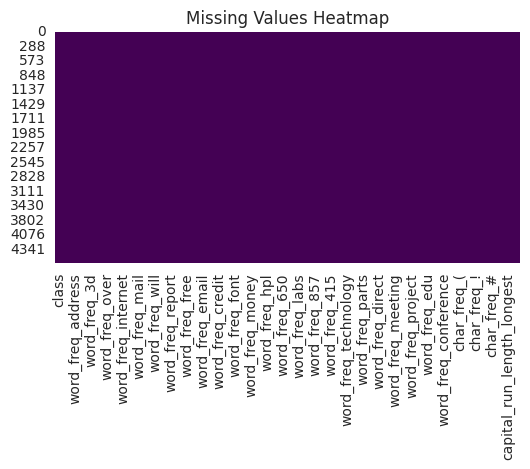

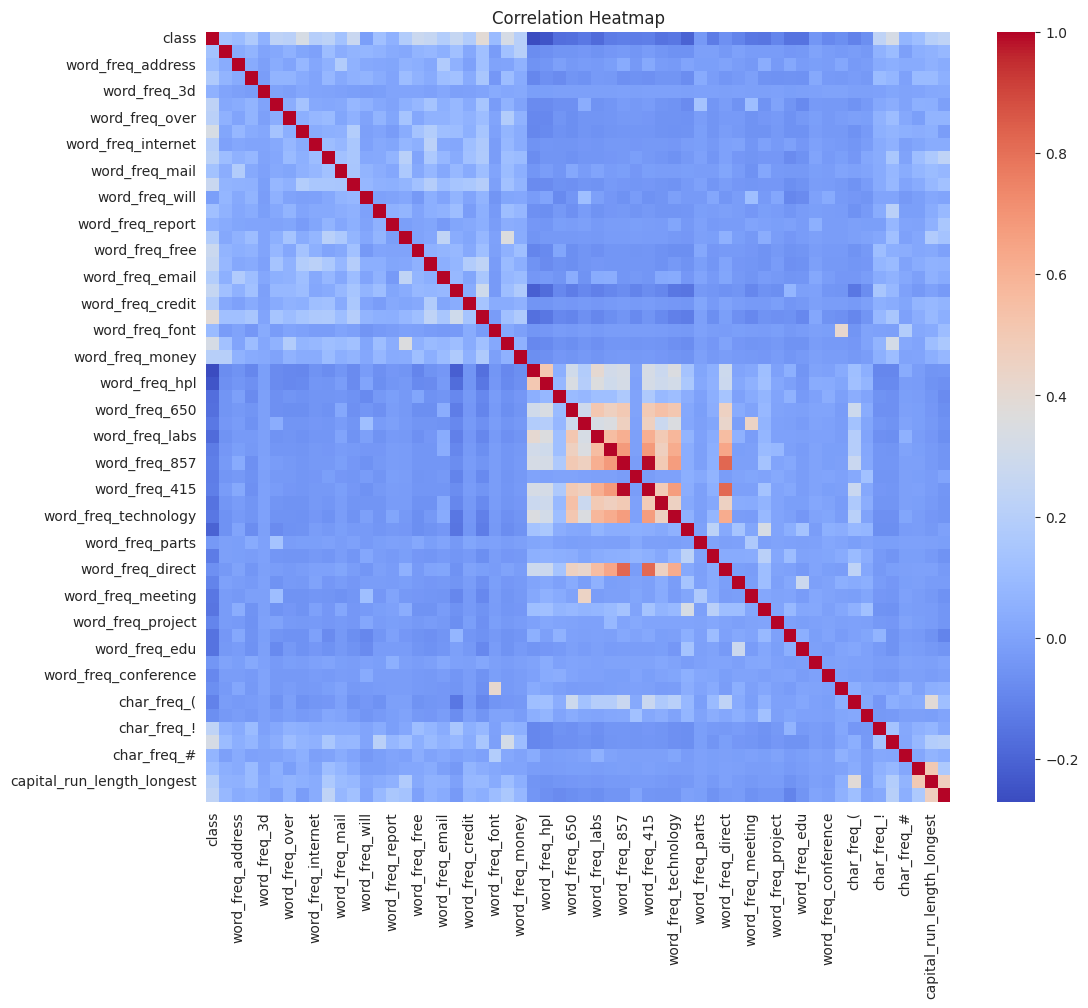

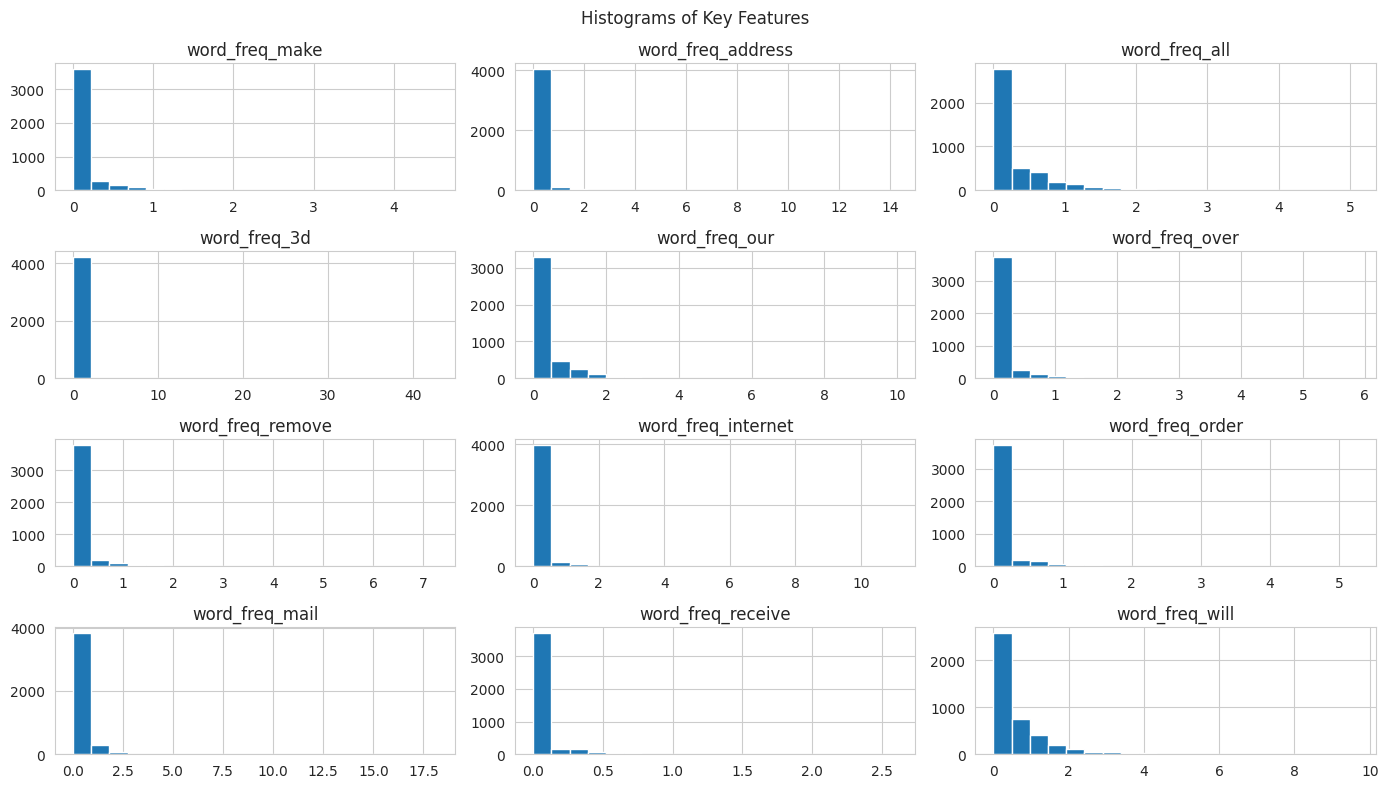

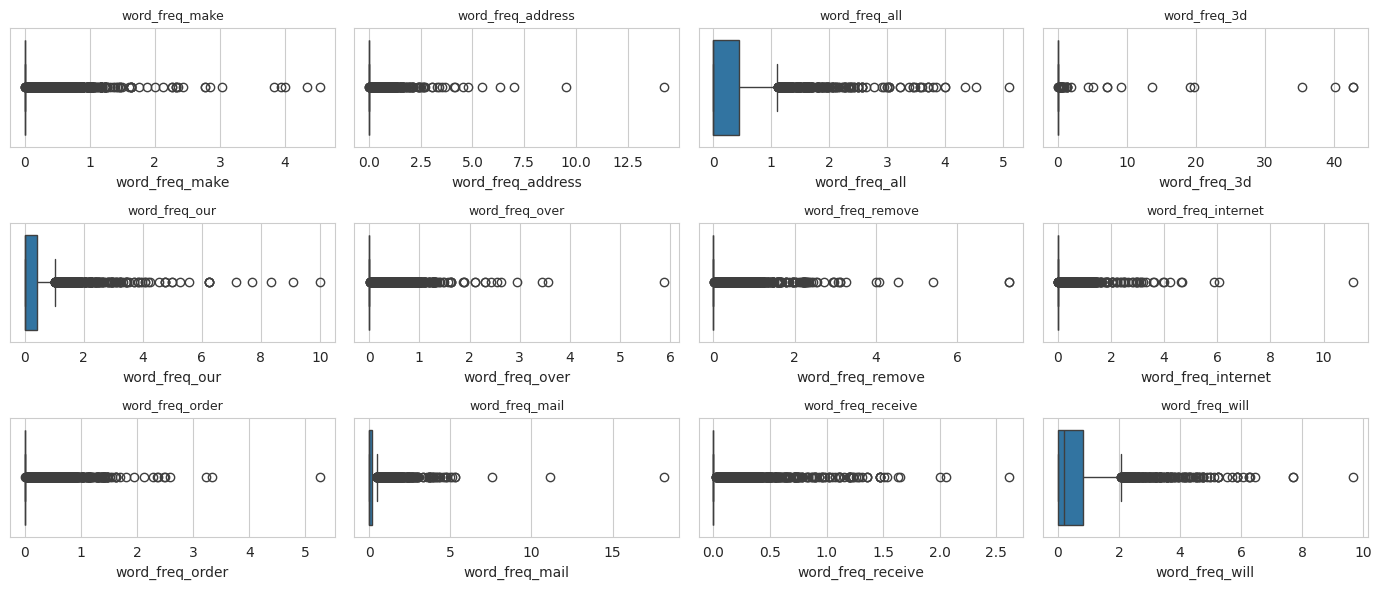

In [4]:
df1 = load_and_preprocess("/home/mtech1/Downloads/Exp1/emailspam/spambase.csv")
print(df1.head())
perform_eda(df1)


Class Distribution
class
0    2531
1    1679
Name: count, dtype: int64
class
0    60.118765
1    39.881235
Name: proportion, dtype: float64


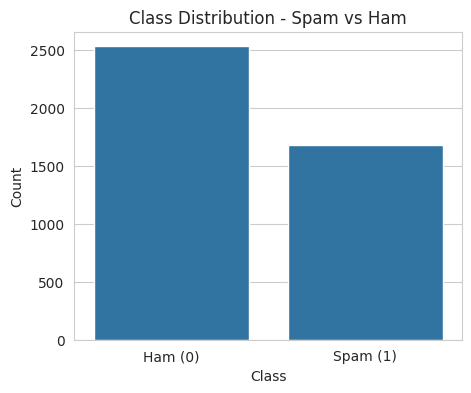

In [5]:
print("Class Distribution")
print(df1["class"].value_counts())
print(df1["class"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(x=df1["class"])
plt.xticks([0, 1], ["Ham (0)", "Spam (1)"])
plt.title("Class Distribution - Spam vs Ham")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [6]:
def detect_task_type(df, target_col, classification_threshold=20):

    target = df[target_col]
    # object dtype OR few unique values -> classification, else regression
    if target.dtype == "object" or target.nunique() <= classification_threshold:
        task = "classification"
    else:
        task = "regression"

    print(f"Target Column : {target_col}")
    print(f"Unique Values : {target.nunique()}")
    print(f"Detected Task : {task}")

    return task


In [7]:
def split_data(df, target_col, task=None, test_size=0.2, val_size=0.1, random_state=42):

    # stratify ensures the same percentage split of classes among train/val/test
    if task is None:
        task = detect_task_type(df, target_col)

    X = df.drop(columns=[target_col])
    y = df[target_col]

    stratify = y if task == "classification" else None

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(test_size + val_size),
        random_state=random_state, stratify=stratify
    )

    stratify_temp = y_temp if task == "classification" else None
    relative_val = val_size / (test_size + val_size)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - relative_val),
        random_state=random_state, stratify=stratify_temp
    )

    print("Train :", X_train.shape)
    print("Val   :", X_val.shape)
    print("Test  :", X_test.shape)

    return X_train, X_val, X_test, y_train, y_val, y_test


In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    df1,
    target_col="class"
)

# Gaussian NB & KNN (Standardized Features)

std_scaler = StandardScaler()

X_train_std = std_scaler.fit_transform(X_train)
X_val_std = std_scaler.transform(X_val)
X_test_std = std_scaler.transform(X_test)

# Multinomial NB (Non-negative Features)

mm_scaler = MinMaxScaler()

X_train_mm = mm_scaler.fit_transform(X_train)
X_val_mm = mm_scaler.transform(X_val)
X_test_mm = mm_scaler.transform(X_test)

# Bernoulli NB (Binary Features)

binarizer = Binarizer(threshold=0.0)

X_train_bin = binarizer.fit_transform(X_train)
X_val_bin = binarizer.transform(X_val)
X_test_bin = binarizer.transform(X_test)


Target Column : class
Unique Values : 2
Detected Task : classification
Train : (2946, 57)
Val   : (421, 57)
Test  : (843, 57)


In [9]:
def train_with_timing(model, X_train, y_train):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    return model, train_time


def predict_with_timing(model, X):
    start = time.time()
    y_pred = model.predict(X)
    predict_time = time.time() - start
    return y_pred, predict_time


In [10]:
# Gaussian Naive Bayes
gnb = GaussianNB()
gnb, gnb_train_time = train_with_timing(gnb, X_train_std, y_train)

# Multinomial Naive Bayes
mnb = MultinomialNB()
mnb, mnb_train_time = train_with_timing(mnb, X_train_mm, y_train)

# Bernoulli Naive Bayes
bnb = BernoulliNB()
bnb, bnb_train_time = train_with_timing(bnb, X_train_bin, y_train)

# K-Nearest Neighbors (default k=5, baseline)
knn = KNeighborsClassifier(n_neighbors=5)
knn, knn_train_time = train_with_timing(knn, X_train_std, y_train)

print("Baseline training times (s)")
print(f"Gaussian NB    : {gnb_train_time:.6f}")
print(f"Multinomial NB : {mnb_train_time:.6f}")
print(f"Bernoulli NB   : {bnb_train_time:.6f}")
print(f"KNN (k=5)      : {knn_train_time:.6f}")


Baseline training times (s)
Gaussian NB    : 0.003920
Multinomial NB : 0.002291
Bernoulli NB   : 0.003264
KNN (k=5)      : 0.001049


In [11]:
def evaluate_model(model, X, y, model_name="Model", dataset_name="Validation"):

    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X)[:, 1]
        roc_auc = roc_auc_score(y, y_proba)
    else:
        y_proba = None
        roc_auc = np.nan

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    cm = confusion_matrix(y, y_pred)

    print("=" * 70)
    print(f"{model_name} - {dataset_name} Set Performance")
    print("=" * 70)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC   : N/A")
    print("\nConfusion Matrix")
    print(cm)
    print()

    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": cm,
        "y_proba": y_proba
    }


In [12]:
baseline_models_val = {
    "Gaussian NB": (gnb, X_val_std),
    "Multinomial NB": (mnb, X_val_mm),
    "Bernoulli NB": (bnb, X_val_bin),
    "KNN (k=5)": (knn, X_val_std)
}

val_results = []

for name, (model, X_data) in baseline_models_val.items():
    result = evaluate_model(model, X_data, y_val, model_name=name, dataset_name="Validation")
    val_results.append(result)

val_results_df = pd.DataFrame(val_results).drop(columns=["Confusion Matrix", "y_proba"])
val_results_df


Gaussian NB - Validation Set Performance
Accuracy  : 0.8219
Precision : 0.7085
Recall    : 0.9405
F1 Score  : 0.8082
ROC-AUC   : 0.9364

Confusion Matrix
[[188  65]
 [ 10 158]]

Multinomial NB - Validation Set Performance
Accuracy  : 0.8812
Precision : 0.9275
Recall    : 0.7619
F1 Score  : 0.8366
ROC-AUC   : 0.9502

Confusion Matrix
[[243  10]
 [ 40 128]]



Bernoulli NB - Validation Set Performance
Accuracy  : 0.8646
Precision : 0.8675
Recall    : 0.7798
F1 Score  : 0.8213
ROC-AUC   : 0.9448

Confusion Matrix
[[233  20]
 [ 37 131]]

KNN (k=5) - Validation Set Performance
Accuracy  : 0.9026
Precision : 0.9097
Recall    : 0.8393
F1 Score  : 0.8731
ROC-AUC   : 0.9387

Confusion Matrix
[[239  14]
 [ 27 141]]



,Model,Dataset,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gaussian NB,Validation,0.821853,0.708520,0.940476,0.808184,0.936418
1,Multinomial NB,Validation,0.881235,0.927536,0.761905,0.836601,0.950169
2,Bernoulli NB,Validation,0.864608,0.867550,0.779762,0.821317,0.944770
3,KNN (k=5),Validation,0.902613,0.909677,0.839286,0.873065,0.938688


### Final Evaluation on Test Set

In [13]:
baseline_models_test = {
    "Gaussian NB": (gnb, X_test_std),
    "Multinomial NB": (mnb, X_test_mm),
    "Bernoulli NB": (bnb, X_test_bin),
    "KNN (k=5)": (knn, X_test_std)
}

test_results = []

for name, (model, X_data) in baseline_models_test.items():
    result = evaluate_model(model, X_data, y_test, model_name=name, dataset_name="Test")
    test_results.append(result)

test_results_df = pd.DataFrame(test_results).drop(columns=["Confusion Matrix", "y_proba"])
test_results_df


Gaussian NB - Test Set Performance
Accuracy  : 0.8363
Precision : 0.7250
Recall    : 0.9494
F1 Score  : 0.8222
ROC-AUC   : 0.9478

Confusion Matrix
[[386 121]
 [ 17 319]]

Multinomial NB - Test Set Performance
Accuracy  : 0.8932
Precision : 0.9489
Recall    : 0.7738
F1 Score  : 0.8525
ROC-AUC   : 0.9592

Confusion Matrix
[[493  14]
 [ 76 260]]

Bernoulli NB - Test Set Performance
Accuracy  : 0.8956
Precision : 0.8827
Recall    : 0.8512
F1 Score  : 0.8667
ROC-AUC   : 0.9562

Confusion Matrix
[[469  38]
 [ 50 286]]



KNN (k=5) - Test Set Performance
Accuracy  : 0.8992
Precision : 0.9061
Recall    : 0.8333
F1 Score  : 0.8682
ROC-AUC   : 0.9464

Confusion Matrix
[[478  29]
 [ 56 280]]



,Model,Dataset,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gaussian NB,Test,0.836299,0.725000,0.949405,0.822165,0.947832
1,Multinomial NB,Test,0.893238,0.948905,0.773810,0.852459,0.959202
2,Bernoulli NB,Test,0.895611,0.882716,0.851190,0.866667,0.956191
3,KNN (k=5),Test,0.899170,0.906149,0.833333,0.868217,0.946373


In [14]:
nb_comparison = test_results_df[
    test_results_df["Model"].isin(["Gaussian NB", "Multinomial NB", "Bernoulli NB"])
].set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]]

nb_comparison_table = nb_comparison.T
nb_comparison_table.columns = ["Gaussian", "Multinomial", "Bernoulli"]
nb_comparison_table.index = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
nb_comparison_table


,Gaussian,Multinomial,Bernoulli
Accuracy,0.836299,0.893238,0.895611
Precision,0.725000,0.948905,0.882716
Recall,0.949405,0.773810,0.851190
F1,0.822165,0.852459,0.866667
ROC-AUC,0.947832,0.959202,0.956191


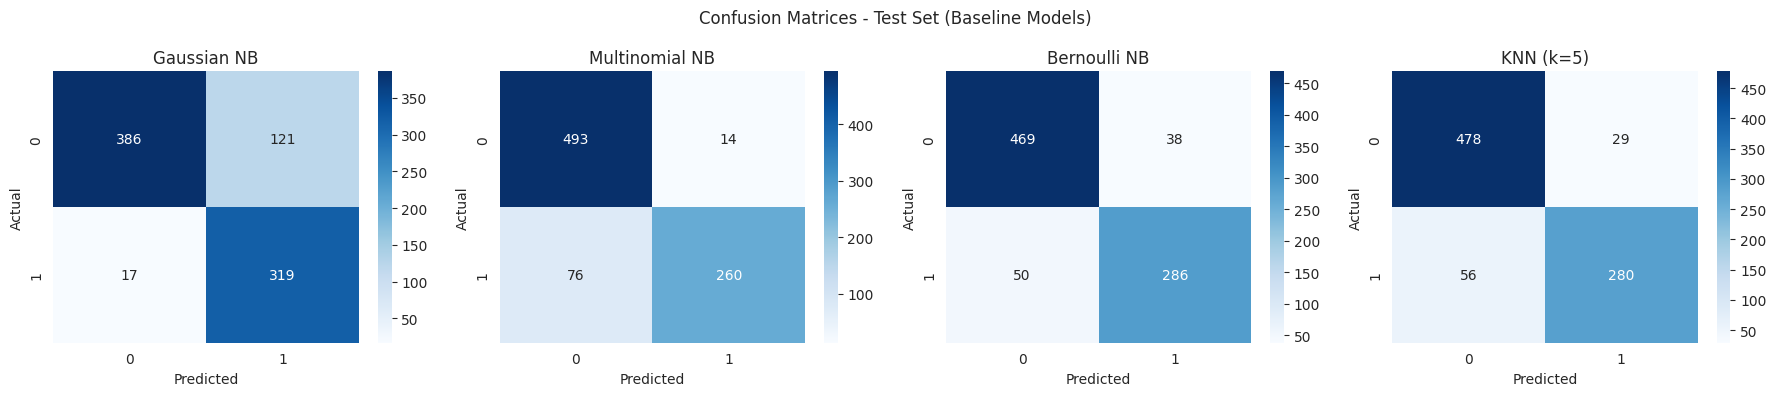

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, result in zip(axes, test_results):
    sns.heatmap(result["Confusion Matrix"], annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(result["Model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices - Test Set (Baseline Models)")
plt.tight_layout()
plt.show()


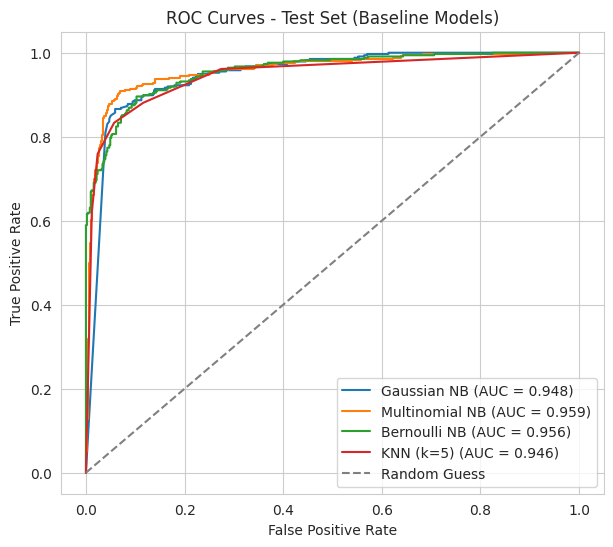

In [16]:
plt.figure(figsize=(7, 6))

for result in test_results:
    if result["y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, result["y_proba"])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{result['Model']} (AUC = {roc_auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Test Set (Baseline Models)")
plt.legend(loc="lower right")
plt.show()


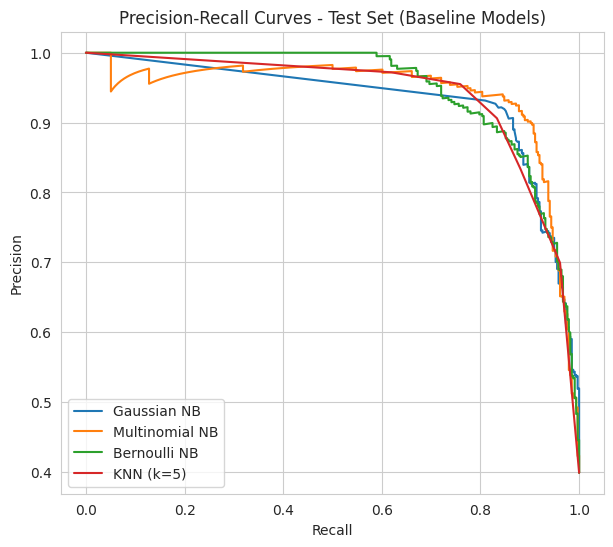

In [17]:
plt.figure(figsize=(7, 6))

for result in test_results:
    if result["y_proba"] is not None:
        precision, recall, _ = precision_recall_curve(y_test, result["y_proba"])
        plt.plot(recall, precision, label=result["Model"])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Test Set (Baseline Models)")
plt.legend(loc="lower left")
plt.show()


In [ ]:
#Effect of Varying k in KNN
k_values = [1, 3, 5, 7, 9, 11]
knn_k_results = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_std, y_train)

    train_pred = knn_k.predict(X_train_std)
    val_pred = knn_k.predict(X_val_std)

    knn_k_results.append({
        "k": k,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(y_val, val_pred, zero_division=0),
        "Recall": recall_score(y_val, val_pred, zero_division=0),
        "F1": f1_score(y_val, val_pred, zero_division=0)
    })

knn_k_df = pd.DataFrame(knn_k_results).set_index("k")
knn_k_df


,Train Accuracy,Accuracy,Precision,Recall,F1
k,,,,,
1,0.998982,0.900238,0.888889,0.857143,0.872727
3,0.940258,0.902613,0.909677,0.839286,0.873065
5,0.926001,0.902613,0.909677,0.839286,0.873065
7,0.920231,0.890736,0.886076,0.833333,0.858896
9,0.917176,0.888361,0.895425,0.815476,0.853583
11,0.914121,0.890736,0.901316,0.815476,0.856250


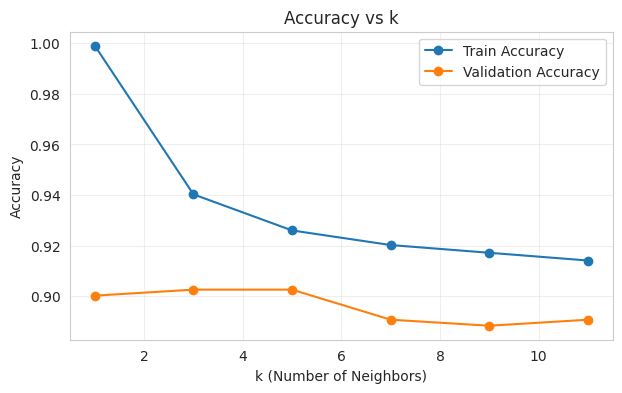

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(knn_k_df.index, knn_k_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(knn_k_df.index, knn_k_df["Accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
#Hyperparameter Tuning - GridSearchCV
param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "kd_tree", "ball_tree"],
    "metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()
grid_search.fit(X_train_std, y_train)
grid_time = time.time() - start

print("Best Params        :", grid_search.best_params_)
print(f"Best CV Accuracy   : {grid_search.best_score_:.4f}")
print(f"Execution Time (s) : {grid_time:.4f}")


Best Params        : {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best CV Accuracy   : 0.9138
Execution Time (s) : 20.5732


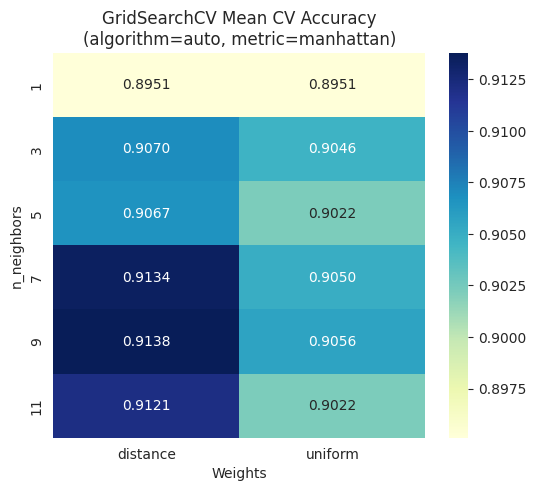

In [21]:
grid_results_df = pd.DataFrame(grid_search.cv_results_)

# Fix algorithm and metric at their best-found values for a clean 2D heatmap
fixed_algo = grid_search.best_params_["algorithm"]
fixed_metric = grid_search.best_params_["metric"]

subset = grid_results_df[
    (grid_results_df["param_algorithm"] == fixed_algo) &
    (grid_results_df["param_metric"] == fixed_metric)
]

pivot = subset.pivot(index="param_n_neighbors", columns="param_weights", values="mean_test_score")

plt.figure(figsize=(6, 5))
sns.heatmap(pivot.astype(float), annot=True, fmt=".4f", cmap="YlGnBu")
plt.title(f"GridSearchCV Mean CV Accuracy\n(algorithm={fixed_algo}, metric={fixed_metric})")
plt.xlabel("Weights")
plt.ylabel("n_neighbors")
plt.show()


In [ ]:
#Hyperparameter Tuning - RandomizedSearchCV
param_dist = {
    "n_neighbors": randint(1, 31),
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "kd_tree", "ball_tree"],
    "metric": ["euclidean", "manhattan"]
}

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

start = time.time()
random_search.fit(X_train_std, y_train)
random_time = time.time() - start

print("Best Params        :", random_search.best_params_)
print(f"Best CV Accuracy   : {random_search.best_score_:.4f}")
print(f"Execution Time (s) : {random_time:.4f}")


Best Params        : {'algorithm': 'ball_tree', 'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best CV Accuracy   : 0.9134
Execution Time (s) : 6.3859


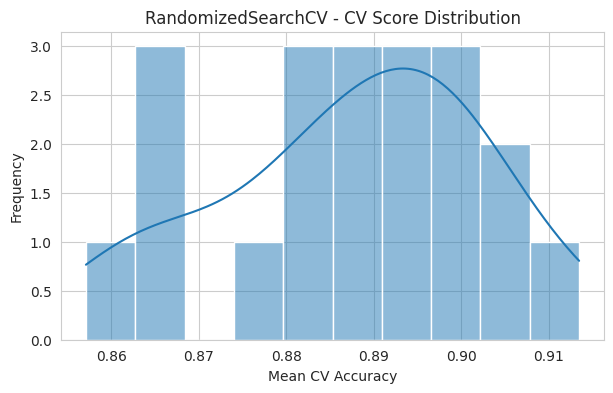

In [ ]:
#RandomizedSearchCV Score Distribution
random_results_df = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(7, 4))
sns.histplot(random_results_df["mean_test_score"], bins=10, kde=True)
plt.title("RandomizedSearchCV - CV Score Distribution")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Frequency")
plt.show()


In [24]:
grid_vs_random = pd.DataFrame({
    "GridSearchCV": [
        grid_search.best_params_["n_neighbors"],
        grid_search.best_params_["metric"],
        grid_search.best_params_["weights"],
        grid_search.best_params_["algorithm"],
        round(grid_search.best_score_, 4),
        round(grid_time, 4)
    ],
    "RandomizedSearchCV": [
        random_search.best_params_["n_neighbors"],
        random_search.best_params_["metric"],
        random_search.best_params_["weights"],
        random_search.best_params_["algorithm"],
        round(random_search.best_score_, 4),
        round(random_time, 4)
    ]
}, index=["Best k", "Metric", "Weights", "Algorithm", "CV Accuracy", "Execution Time (s)"])

grid_vs_random


,GridSearchCV,RandomizedSearchCV
Best k,9,7
Metric,manhattan,manhattan
Weights,distance,distance
Algorithm,auto,ball_tree
CV Accuracy,0.9138,0.9134
Execution Time (s),20.5732,6.3859


In [25]:
if grid_search.best_score_ >= random_search.best_score_:
    best_knn = grid_search.best_estimator_
    best_search_name = "GridSearchCV"
else:
    best_knn = random_search.best_estimator_
    best_search_name = "RandomizedSearchCV"

print(f"Selected tuned KNN from: {best_search_name}")
print("Params:", best_knn.get_params())


Selected tuned KNN from: GridSearchCV
Params: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 9, 'p': 2, 'weights': 'distance'}


In [ ]:
#KDTree vs BallTree Comparison
best_k = grid_search.best_params_["n_neighbors"]
best_weights = grid_search.best_params_["weights"]
best_metric = grid_search.best_params_["metric"]

tree_results = []

for algo in ["kd_tree", "ball_tree"]:
    knn_tree = KNeighborsClassifier(
        n_neighbors=best_k,
        weights=best_weights,
        metric=best_metric,
        algorithm=algo
    )

    knn_tree, tree_train_time = train_with_timing(knn_tree, X_train_std, y_train)
    y_pred, tree_predict_time = predict_with_timing(knn_tree, X_test_std)

    acc = accuracy_score(y_test, y_pred)

    tree_results.append({
        "Algorithm": algo,
        "Accuracy": acc,
        "Training Time (s)": tree_train_time,
        "Prediction Time (s)": tree_predict_time
    })

tree_comparison_df = pd.DataFrame(tree_results)
tree_comparison_df


,Algorithm,Accuracy,Training Time (s),Prediction Time (s)
0,kd_tree,0.918149,0.016109,0.136835
1,ball_tree,0.918149,0.008360,0.089179


In [ ]:
#5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pick the best-performing Naive Bayes variant (by validation F1) to carry into cross-validation
nb_val = val_results_df[val_results_df["Model"].isin(["Gaussian NB", "Multinomial NB", "Bernoulli NB"])]
best_nb_name = nb_val.sort_values("F1 Score", ascending=False).iloc[0]["Model"]

nb_lookup = {
    "Gaussian NB": (GaussianNB(), X_train_std),
    "Multinomial NB": (MultinomialNB(), X_train_mm),
    "Bernoulli NB": (BernoulliNB(), X_train_bin)
}
best_nb_model, best_nb_X = nb_lookup[best_nb_name]

nb_cv_scores = cross_val_score(best_nb_model, best_nb_X, y_train, cv=skf, scoring="accuracy")
knn_cv_scores = cross_val_score(best_knn, X_train_std, y_train, cv=skf, scoring="accuracy")

cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    f"Naive Bayes ({best_nb_name})": nb_cv_scores,
    "Best KNN": knn_cv_scores
})

avg_row = pd.DataFrame({
    "Fold": ["Average"],
    f"Naive Bayes ({best_nb_name})": [nb_cv_scores.mean()],
    "Best KNN": [knn_cv_scores.mean()]
})

cv_table = pd.concat([cv_table, avg_row], ignore_index=True)
cv_table


,Fold,Naive Bayes (Multinomial NB),Best KNN
0,1,0.908475,0.915254
1,2,0.869270,0.911715
2,3,0.886248,0.925297
3,4,0.877759,0.906621
4,5,0.884550,0.904924
5,Average,0.885260,0.912762


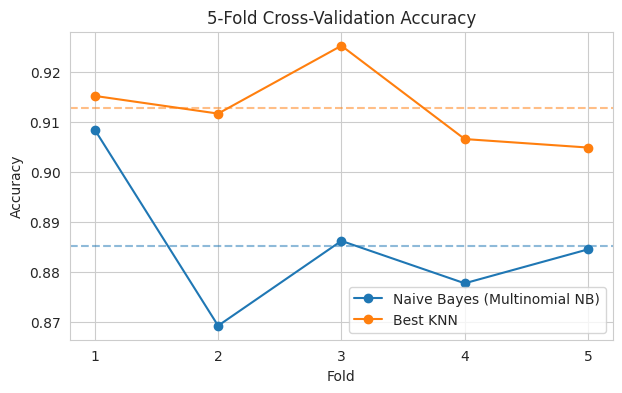

In [28]:
fold_labels = [1, 2, 3, 4, 5]

plt.figure(figsize=(7, 4))
plt.plot(fold_labels, nb_cv_scores, marker="o", label=f"Naive Bayes ({best_nb_name})")
plt.plot(fold_labels, knn_cv_scores, marker="o", label="Best KNN")
plt.axhline(nb_cv_scores.mean(), linestyle="--", alpha=0.5, color="C0")
plt.axhline(knn_cv_scores.mean(), linestyle="--", alpha=0.5, color="C1")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.xticks(fold_labels)
plt.legend()
plt.show()


In [29]:
timing_configs = {
    "Gaussian NB": (GaussianNB(), X_train_std, X_test_std),
    "Multinomial NB": (MultinomialNB(), X_train_mm, X_test_mm),
    "Bernoulli NB": (BernoulliNB(), X_train_bin, X_test_bin),
    "Best KNN": (KNeighborsClassifier(**best_knn.get_params()), X_train_std, X_test_std)
}

timing_results = []

for name, (model, Xtr, Xte) in timing_configs.items():
    model, t_train = train_with_timing(model, Xtr, y_train)
    _, t_predict = predict_with_timing(model, Xte)
    timing_results.append({
        "Algorithm": name,
        "Training Time (s)": t_train,
        "Prediction Time (s)": t_predict
    })

timing_df = pd.DataFrame(timing_results)
timing_df


,Algorithm,Training Time (s),Prediction Time (s)
0,Gaussian NB,0.009531,0.000600
1,Multinomial NB,0.002012,0.000196
2,Bernoulli NB,0.003335,0.000851
3,Best KNN,0.000843,0.073940


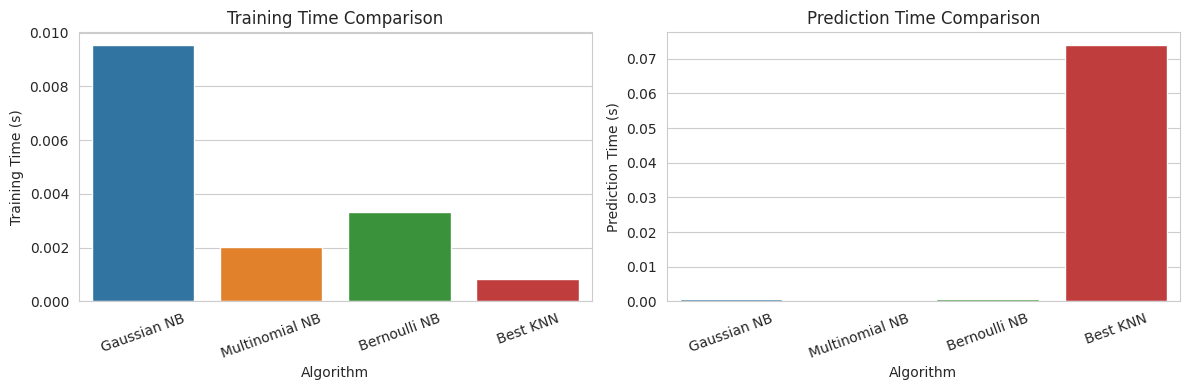

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=timing_df, x="Algorithm", y="Training Time (s)", ax=axes[0], hue="Algorithm", legend=False)
axes[0].set_title("Training Time Comparison")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=timing_df, x="Algorithm", y="Prediction Time (s)", ax=axes[1], hue="Algorithm", legend=False)
axes[1].set_title("Prediction Time Comparison")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [31]:
final_models_test = {
    "Gaussian NB": (gnb, X_test_std),
    "Multinomial NB": (mnb, X_test_mm),
    "Bernoulli NB": (bnb, X_test_bin),
    "Best KNN": (best_knn, X_test_std)
}

final_results = []

for name, (model, X_data) in final_models_test.items():
    result = evaluate_model(model, X_data, y_test, model_name=name, dataset_name="Test")
    final_results.append(result)

final_results_df = pd.DataFrame(final_results).drop(columns=["Confusion Matrix", "y_proba"])
final_results_df


Gaussian NB - Test Set Performance
Accuracy  : 0.8363
Precision : 0.7250
Recall    : 0.9494
F1 Score  : 0.8222
ROC-AUC   : 0.9478

Confusion Matrix
[[386 121]
 [ 17 319]]

Multinomial NB - Test Set Performance
Accuracy  : 0.8932
Precision : 0.9489
Recall    : 0.7738
F1 Score  : 0.8525
ROC-AUC   : 0.9592

Confusion Matrix
[[493  14]
 [ 76 260]]

Bernoulli NB - Test Set Performance
Accuracy  : 0.8956
Precision : 0.8827
Recall    : 0.8512
F1 Score  : 0.8667
ROC-AUC   : 0.9562

Confusion Matrix
[[469  38]
 [ 50 286]]

Best KNN - Test Set Performance
Accuracy  : 0.9181
Precision : 0.9406
Recall    : 0.8482
F1 Score  : 0.8920
ROC-AUC   : 0.9702

Confusion Matrix
[[489  18]
 [ 51 285]]



,Model,Dataset,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gaussian NB,Test,0.836299,0.725000,0.949405,0.822165,0.947832
1,Multinomial NB,Test,0.893238,0.948905,0.773810,0.852459,0.959202
2,Bernoulli NB,Test,0.895611,0.882716,0.851190,0.866667,0.956191
3,Best KNN,Test,0.918149,0.940594,0.848214,0.892019,0.970188


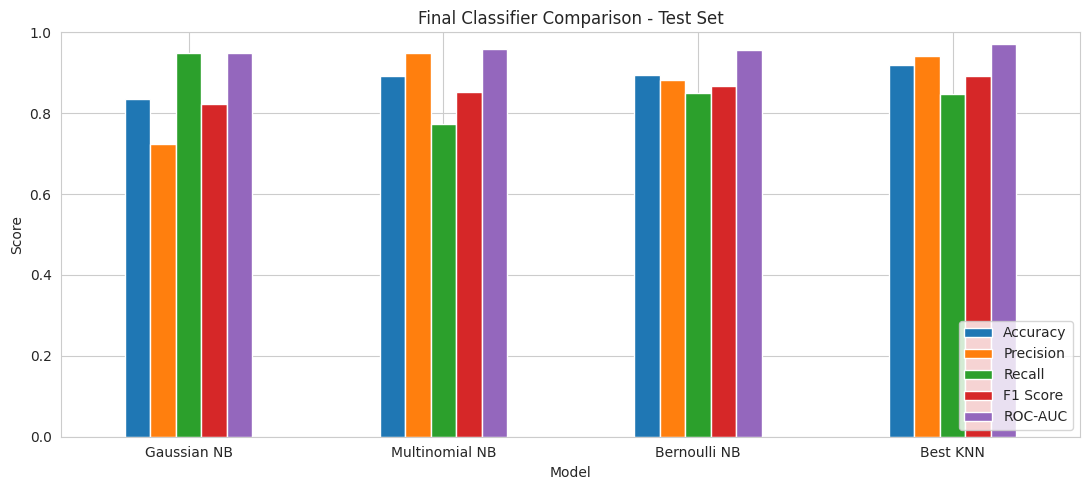

In [32]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

plot_df = final_results_df.set_index("Model")[metrics]

plot_df.plot(kind="bar", figsize=(11, 5))
plt.title("Final Classifier Comparison - Test Set")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


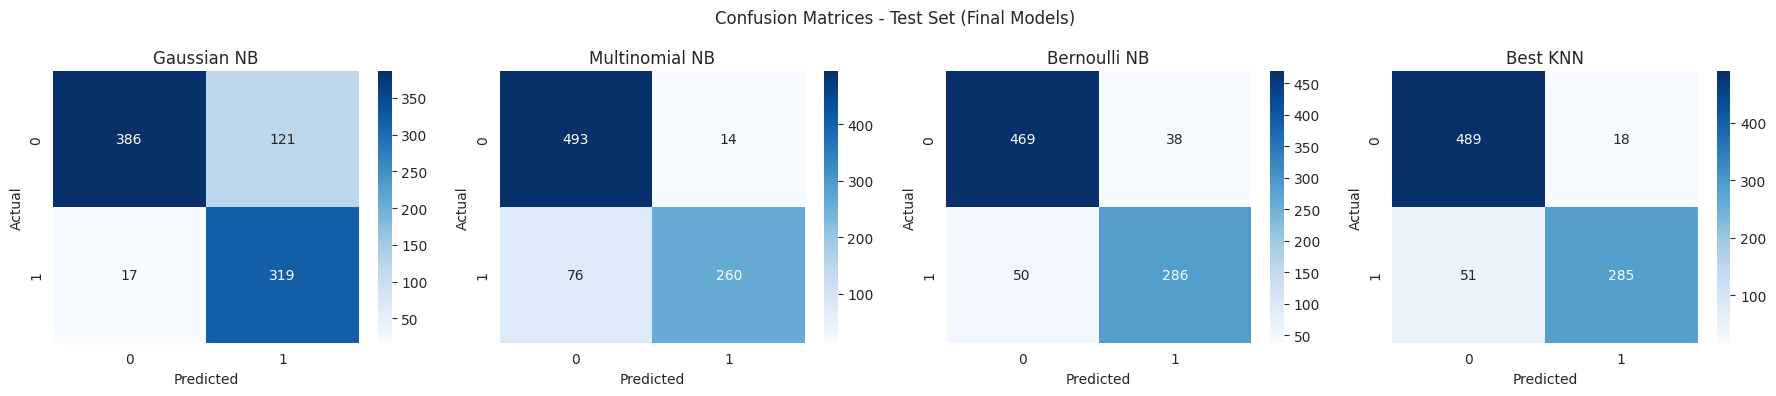

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, result in zip(axes, final_results):
    sns.heatmap(result["Confusion Matrix"], annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(result["Model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices - Test Set (Final Models)")
plt.tight_layout()
plt.show()


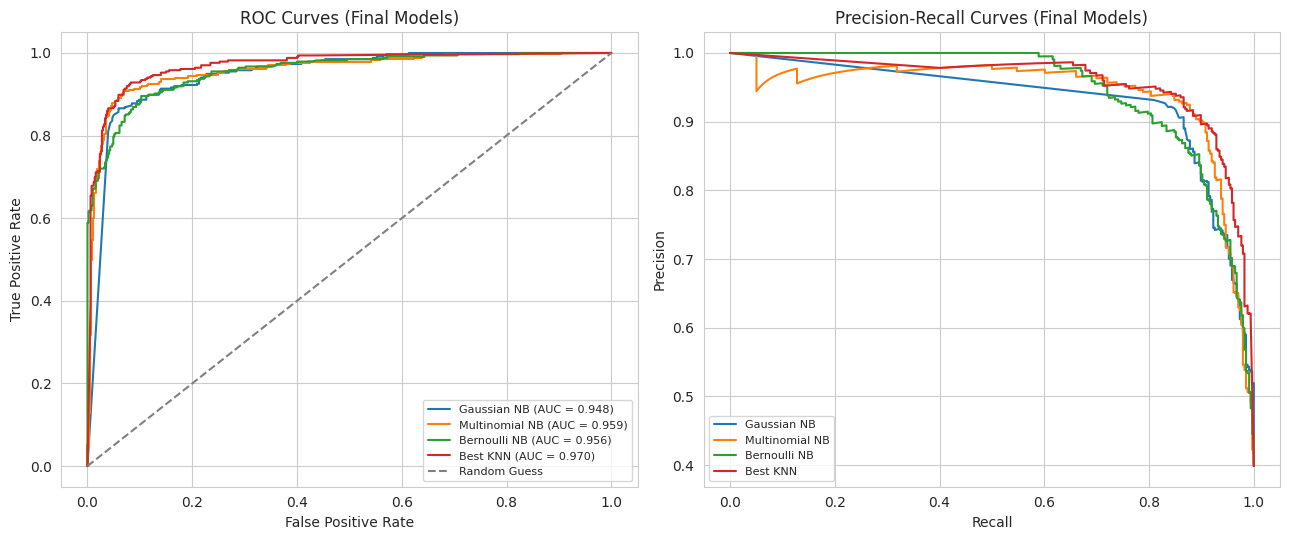

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for result in final_results:
    if result["y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, result["y_proba"])
        roc_auc_val = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, label=f"{result['Model']} (AUC = {roc_auc_val:.3f})")

        precision, recall, _ = precision_recall_curve(y_test, result["y_proba"])
        axes[1].plot(recall, precision, label=result["Model"])

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (Final Models)")
axes[0].legend(loc="lower right", fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (Final Models)")
axes[1].legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()


In [35]:
split_ratios = [0.4, 0.3, 0.2, 0.1]  # test set proportion

X_full = df1.drop(columns=["class"])
y_full = df1["class"]

split_task_results = []

for test_size in split_ratios:
    Xtr, Xte, ytr, yte = train_test_split(
        X_full, y_full, test_size=test_size, random_state=42, stratify=y_full
    )

    scaler_tmp = StandardScaler()
    Xtr_scaled = scaler_tmp.fit_transform(Xtr)
    Xte_scaled = scaler_tmp.transform(Xte)

    knn_tmp = KNeighborsClassifier(**best_knn.get_params())
    knn_tmp.fit(Xtr_scaled, ytr)
    knn_acc = accuracy_score(yte, knn_tmp.predict(Xte_scaled))

    nb_tmp = GaussianNB()
    nb_tmp.fit(Xtr_scaled, ytr)
    nb_acc = accuracy_score(yte, nb_tmp.predict(Xte_scaled))

    split_task_results.append({
        "Train:Test": f"{int(round((1 - test_size) * 100))}:{int(round(test_size * 100))}",
        "Gaussian NB Accuracy": nb_acc,
        "Best KNN Accuracy": knn_acc
    })

split_task_df = pd.DataFrame(split_task_results)
split_task_df


,Train:Test,Gaussian NB Accuracy,Best KNN Accuracy
0,60:40,0.827197,0.916865
1,70:30,0.831354,0.920032
2,80:20,0.828979,0.927553
3,90:10,0.821853,0.933492


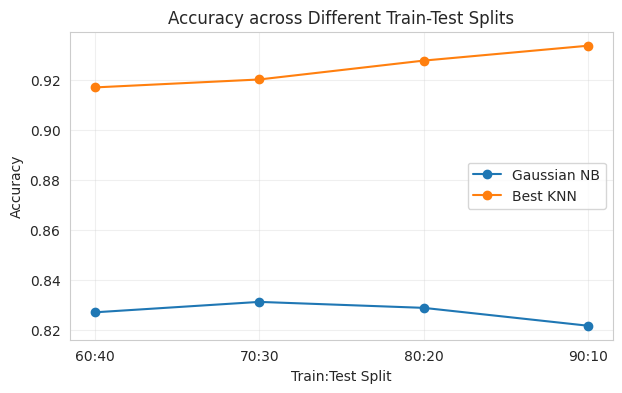

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(split_task_df["Train:Test"], split_task_df["Gaussian NB Accuracy"], marker="o", label="Gaussian NB")
plt.plot(split_task_df["Train:Test"], split_task_df["Best KNN Accuracy"], marker="o", label="Best KNN")
plt.xlabel("Train:Test Split")
plt.ylabel("Accuracy")
plt.title("Accuracy across Different Train-Test Splits")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [37]:
distance_results = []

for metric in ["euclidean", "manhattan"]:
    knn_dist = KNeighborsClassifier(
        n_neighbors=best_knn.get_params()["n_neighbors"],
        weights=best_knn.get_params()["weights"],
        metric=metric
    )
    knn_dist.fit(X_train_std, y_train)
    pred = knn_dist.predict(X_test_std)

    distance_results.append({
        "Distance Metric": metric,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0)
    })

distance_df = pd.DataFrame(distance_results)
distance_df


,Distance Metric,Accuracy,Precision,Recall,F1 Score
0,euclidean,0.915777,0.923323,0.860119,0.890601
1,manhattan,0.918149,0.940594,0.848214,0.892019


In [38]:
weight_results = []

for weight in ["uniform", "distance"]:
    knn_w = KNeighborsClassifier(
        n_neighbors=best_knn.get_params()["n_neighbors"],
        weights=weight,
        metric=best_knn.get_params()["metric"]
    )
    knn_w.fit(X_train_std, y_train)
    pred = knn_w.predict(X_test_std)

    weight_results.append({
        "Weights": weight,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0)
    })

weight_df = pd.DataFrame(weight_results)
weight_df


,Weights,Accuracy,Precision,Recall,F1 Score
0,uniform,0.902728,0.931973,0.815476,0.869841
1,distance,0.918149,0.940594,0.848214,0.892019


In [40]:
best_model_row = final_results_df.loc[final_results_df["F1 Score"].idxmax()]

print("=" * 70)
print("BEST OVERALL MODEL (based on Test F1 Score)")
print("=" * 70)
print(best_model_row.to_string())


BEST OVERALL MODEL (based on Test F1 Score)
Model        Best KNN
Dataset          Test
Accuracy     0.918149
Precision    0.940594
Recall       0.848214
F1 Score     0.892019
ROC-AUC      0.970188
